In [1]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from process_ccf import process_ccf_dataset
from process_ccf import concat_ccf_csv_files



2026-04-13 10:41:55.299889: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 10:41:55.318486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776073315.340504   21861 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776073315.347101   21861 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776073315.363904   21861 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

From the notebook, you can run it with:

!python merge_snr_iccf_datasets.py
That will:

merge all CSVs with the same SNR
normalize those merged CCFs
save one parquet per SNR in CCFs/
save CCFs/random_rv_iccf_datasets_snr_merged_normalized.parquet
back up the old CCFs/full_iccf_dataset_normalized.parquet
overwrite CCFs/full_iccf_dataset_normalized.parquet with the combined dataset
If you want to only create the SNR parquet files and not touch the full parquet yet:

!python merge_snr_iccf_datasets.py --skip-append-to-full

In [ ]:
#!python merge_snr_iccf_datasets.py
#!python merge_snr_iccf_datasets.py --skip-append-to-full



Found 2156 CSV files across 22 SNR groups.
/home/vadibekyan/Exoplanets/scientific_projects/AI/RV/DL_RV_diogo/merge_snr_iccf_datasets.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["dataset_label"] = f"active_snr_{snr}"
SNR 20p0: 98 files -> 9800 rows
/home/vadibekyan/Exoplanets/scientific_projects/AI/RV/DL_RV_diogo/merge_snr_iccf_datasets.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["dataset_label"] = f"active_snr_{snr}"
SNR 25p0: 98 files -> 9800 rows
/home/vadibekyan/Exoplanets/scientific_pr

In [ ]:
#quiet_output_file = "./CCFs/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1_normalized.parquet"
#merged_input_dir = "./hpc_results/random_rv_iccf_datasets_1000"
#merged_csv_file = "./hpc_results/random_rv_iccf_datasets_1000_merged.csv"
#merged_output_file = "./CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet"

#merged_df = concat_ccf_csv_files(
#    merged_input_dir,
#    output_path=merged_csv_file,
#)

In [ ]:
#process_ccf_dataset(merged_csv_file, merged_output_file)

Loading hpc_results/random_rv_iccf_datasets_1000_merged.csv...
Rounded rv_true_mps to 2 decimals
Normalized CCFs
Rounded CCFs to 4 decimals
Saving to CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet...
Done!


In [7]:
full_df = pd.read_parquet("./CCFs/full_iccf_dataset_normalized.parquet")
full_df
                          

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300,dataset_label
0,77.40,-146.693695,6.597320,-35.303705,-28.251487,-603.388779,56.713954,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9881,quiet
1,43.89,-180.204276,6.597626,-35.453621,-27.440173,-603.794378,56.714368,0.9788,0.9788,0.9787,...,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9882,0.9881,quiet
2,85.86,-138.228632,6.597244,-35.267085,-28.472872,-603.333098,56.713862,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881,quiet
3,69.74,-154.353225,6.597390,-35.335859,-28.055823,-603.456774,56.714041,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9882,0.9881,quiet
4,9.42,-214.676058,6.597961,-35.210673,-29.142251,-601.875318,56.714733,0.9788,0.9787,0.9787,...,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881,0.9881,quiet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745595,63.03,-149.005651,5.771171,-41.514446,-33.136732,-958.922600,65.845183,0.9727,0.9727,0.9726,...,0.9824,0.9824,0.9825,0.9825,0.9825,0.9826,0.9827,0.9828,0.9829,active_snr_350p0
745596,36.18,-175.853160,5.771350,-41.479025,-36.087525,-959.659080,65.845406,0.9727,0.9727,0.9726,...,0.9824,0.9825,0.9825,0.9825,0.9826,0.9826,0.9827,0.9828,0.9829,active_snr_350p0
745597,8.76,-203.271292,5.771545,-41.672195,-35.112241,-958.081835,65.845559,0.9727,0.9726,0.9726,...,0.9824,0.9825,0.9825,0.9825,0.9826,0.9827,0.9827,0.9828,0.9829,active_snr_350p0
745598,11.80,-200.235533,5.771523,-41.652126,-35.222315,-958.068670,65.845547,0.9727,0.9726,0.9726,...,0.9824,0.9825,0.9825,0.9825,0.9826,0.9827,0.9827,0.9828,0.9829,active_snr_350p0


In [19]:
set(full_df['dataset_label'])

{'active',
 'active_snr_100p0',
 'active_snr_110p0',
 'active_snr_120p0',
 'active_snr_130p0',
 'active_snr_140p0',
 'active_snr_150p0',
 'active_snr_170p0',
 'active_snr_200p0',
 'active_snr_20p0',
 'active_snr_250p0',
 'active_snr_25p0',
 'active_snr_300p0',
 'active_snr_30p0',
 'active_snr_350p0',
 'active_snr_35p0',
 'active_snr_40p0',
 'active_snr_45p0',
 'active_snr_50p0',
 'active_snr_60p0',
 'active_snr_70p0',
 'active_snr_80p0',
 'active_snr_90p0',
 'quiet'}

In [20]:
full_df[full_df['dataset_label'] == 'active_snr_20p0']

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300,dataset_label
530000,77.40,-145.013498,6.595086,-32.530030,-24.782581,-606.149935,56.723254,0.9776,0.9771,0.9763,...,0.9870,0.9868,0.9867,0.9868,0.9871,0.9874,0.9875,0.9873,0.9866,active_snr_20p0
530001,43.89,-178.523489,6.595356,-32.682199,-23.993219,-606.205595,56.723573,0.9775,0.9769,0.9760,...,0.9869,0.9867,0.9867,0.9869,0.9872,0.9874,0.9875,0.9871,0.9863,active_snr_20p0
530002,85.86,-136.548080,6.595018,-32.492785,-25.000070,-606.180082,56.723183,0.9776,0.9771,0.9764,...,0.9870,0.9868,0.9867,0.9868,0.9871,0.9873,0.9875,0.9873,0.9867,active_snr_20p0
530003,69.74,-152.673130,6.595144,-32.564454,-24.590340,-606.147905,56.723324,0.9776,0.9770,0.9763,...,0.9870,0.9867,0.9867,0.9869,0.9871,0.9874,0.9875,0.9872,0.9865,active_snr_20p0
530004,9.42,-212.995312,6.595664,-32.433689,-25.655398,-605.125161,56.723946,0.9773,0.9766,0.9758,...,0.9868,0.9867,0.9868,0.9870,0.9873,0.9875,0.9874,0.9869,0.9861,active_snr_20p0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539795,63.03,-147.435128,5.771146,-36.014264,-27.735343,-967.484429,65.877128,0.9700,0.9700,0.9699,...,0.9809,0.9805,0.9802,0.9796,0.9792,0.9789,0.9789,0.9791,0.9794,active_snr_20p0
539796,36.18,-174.281248,5.771317,-35.982424,-30.066974,-968.497186,65.877320,0.9700,0.9700,0.9699,...,0.9808,0.9804,0.9801,0.9795,0.9791,0.9790,0.9790,0.9792,0.9796,active_snr_20p0
539797,8.76,-201.701522,5.771506,-36.186993,-29.164498,-966.198020,65.877457,0.9700,0.9700,0.9699,...,0.9807,0.9803,0.9800,0.9794,0.9790,0.9789,0.9790,0.9793,0.9797,active_snr_20p0
539798,11.80,-198.665566,5.771485,-36.167452,-29.268716,-969.089569,65.877446,0.9700,0.9700,0.9699,...,0.9807,0.9803,0.9800,0.9794,0.9790,0.9789,0.9790,0.9793,0.9797,active_snr_20p0


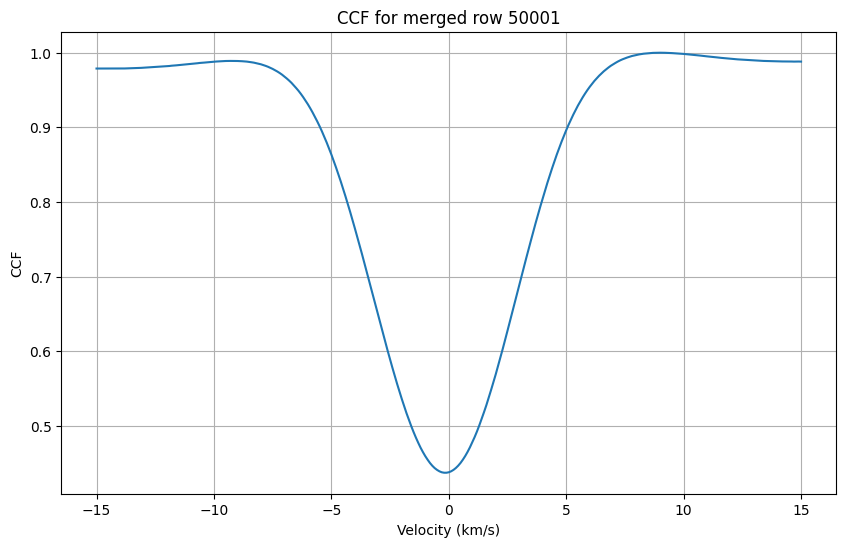

In [23]:
# Plot CCF for a given row
row_index = 50001  # Change this to the desired row index
velocities = np.arange(-15, 15.1, 0.1)
ccf_columns = [f'ccf_{i:04d}' for i in range(301)]
ccf_values = full_df.loc[row_index, ccf_columns].values

plt.figure(figsize=(10, 6))
plt.plot(velocities, ccf_values)
plt.xlabel('Velocity (km/s)')
plt.ylabel('CCF')
plt.title(f'CCF for merged row {row_index}')
plt.grid(True)
plt.show()

In [13]:
ccf_cols = [c for c in full_df.columns if c.startswith("ccf_")]

X = full_df[ccf_cols].to_numpy(dtype=np.float32)
y = pd.to_numeric(full_df["rv_true_mps"], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1)

In [14]:
# Split merged quiet+active dataset into train/dev/test: 70% / 15% / 15%
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, shuffle=True
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Dev:  ", X_dev.shape, y_dev.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (521920, 301) (521920, 1)
Dev:   (111840, 301) (111840, 1)
Test:  (111840, 301) (111840, 1)


In [15]:
# Scale features and target for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_dev_s = x_scaler.transform(X_dev)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train)
y_dev_s = y_scaler.transform(y_dev)
y_test_s = y_scaler.transform(y_test)


In [16]:
# Simple MLP baseline
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    #layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.7,
        patience=10,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]


history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_dev_s, y_dev_s),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


2026-04-13 13:13:01.202459: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0627 - mae: 0.1384 - val_loss: 0.0090 - val_mae: 0.0671 - learning_rate: 0.0010
Epoch 2/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0107 - mae: 0.0675 - val_loss: 0.0097 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 3/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0084 - mae: 0.0554 - val_loss: 0.0067 - val_mae: 0.0469 - learning_rate: 0.0010
Epoch 4/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0071 - mae: 0.0489 - val_loss: 0.0069 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 5/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0063 - mae: 0.0446 - val_loss: 0.0054 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 6/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0057 - mae: 0.0409 - val_loss: 0.0051 - val_mae: 0.0365 - learning_rate: 0.0010
Epoch 7/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0053 - mae: 0.0382 - val_loss: 0.0048 - val_mae: 0.0341 - learnin

In [17]:
def evaluate_regression(model, X_s, y_true, scaler, split_name):
    y_pred_s = model.predict(X_s, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_s).ravel()
    y_true = y_true.ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return y_pred

y_dev_pred = evaluate_regression(model, X_dev_s, y_dev, y_scaler, "Dev")
y_test_pred = evaluate_regression(model, X_test_s, y_test, y_scaler, "Test")


Dev -> MAE: 0.470713, RMSE: 0.691750, R2: 0.999409
Test -> MAE: 0.468415, RMSE: 0.688086, R2: 0.999412


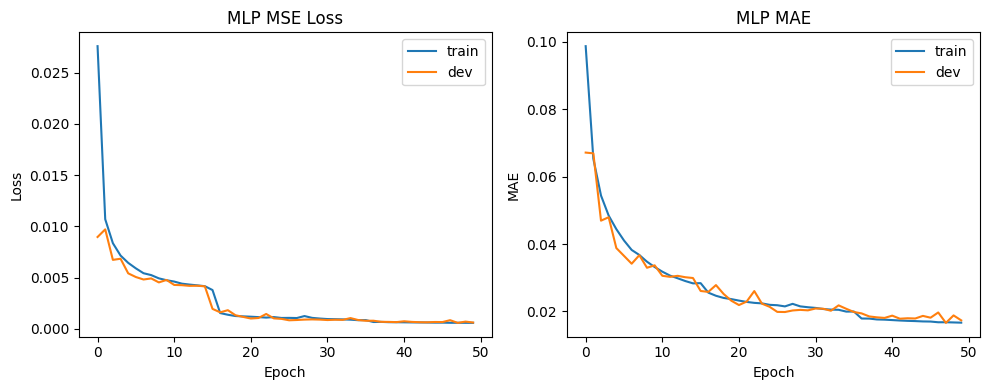

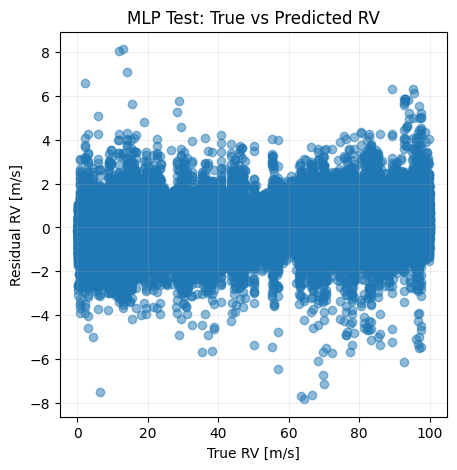

In [18]:
# MLP training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="dev")
plt.title("MLP MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="dev")
plt.title("MLP MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# MLP prediction scatter on test split
plt.figure(figsize=(5, 5))
plt.scatter(y_test.ravel(), y_test.ravel() - y_test_pred, alpha=0.5)
min_v = min(y_test.min(), y_test_pred.min())
max_v = max(y_test.max(), y_test_pred.max())
#plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("MLP Test: True vs Predicted RV")
plt.grid(True, alpha=0.2)
plt.show()
